# Predicting 30-Day Hospital Readmission in Diabetic Patients
## A Distributed Machine Learning Approach - Apache Spark MLlib

**Course:** Big Data Analytics and Text Mining - Module 2  
**University:** Università di Bologna - MSc Artificial Intelligence  

---

## Library Versions

| Library | Version |
|---|---|
| PySpark | 3.5.x |
| Python | 3.10+ |
| pandas | 2.0.x |
| matplotlib | 3.7.x |
| seaborn | 0.12.x |
| scikit-learn | 1.3.x |
| xgboost | 2.0.x |

---

## Dataset
- **Source:** UCI Machine Learning Repository  
- **Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008  
- **Records:** 101,766 patient visits | **Features:** 50 clinical variables  
- **Reference:** Strack et al. (2014), BioMed Research International

---

## Research Questions
1. Can we reliably predict 30-day readmission from clinical features available at discharge?
2. Which features carry the most predictive weight?
3. Does model performance differ significantly across patient age groups?
4. Does feature engineering improve predictive performance?
5. How does class weighting affect results on imbalanced data?

---

## ML Algorithms

| # | Algorithm | Imbalance Strategy | Notes |
|---|---|---|---|
| 1 | Decision Tree | Class Weights | Most interpretable - clinical rules |
| 2 | Random Forest | Class Weights | Feature importance ranking |
| 3 | XGBoost | Class Weights | Best overall discriminator |


In [ ]:
# Core Spark
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, udf, rank, lit
from pyspark.sql.types import StringType, IntegerType

# Spark ML
from pyspark.ml.feature import RFormula
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)
from pyspark.ml.functions import vector_to_array

# External
from sklearn.metrics import roc_curve, auc as sk_auc
from functools import reduce as fred
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")


All imports successful


In [ ]:
spark = SparkSession.builder \
    .appName("DiabetesReadmission") \
    .master("spark://localhost:7077") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")


In [ ]:
import urllib.request, zipfile, os

URL = ("https://archive.ics.uci.edu/static/public/296/"
       "diabetes+130-us+hospitals+for+years+1999-2008.zip")

if not os.path.exists("diabetic_data.csv"):
    print("Downloading dataset from UCI...")
    urllib.request.urlretrieve(URL, "diabetes.zip")
    with zipfile.ZipFile("diabetes.zip", "r") as z:
        z.extractall(".")
    print("Downloaded")
else:
    print("Already exists")

df = spark.read.csv("diabetic_data.csv", header=True, inferSchema=True)
df = df.toDF(*[c.strip() for c in df.columns])
print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")


Downloaded
Rows    : 101,766
Columns : 50


In [ ]:
# Check missing values (represented as '?')
print("Missing value check (? counts per column):")
for column, dtype in df.dtypes:
    if dtype == "string":
        count = df.filter(col(column) == "?").count()
        if count > 0:
            print(f"  {column:<30}: {count:,}")


Missing value check (? counts per column):
  race                          : 2,273
  weight                        : 98,569
  payer_code                    : 40,256
  medical_specialty             : 49,949
  diag_1                        : 21
  diag_2                        : 358
  diag_3                        : 1,423


## Preprocessing

Ten preprocessing steps applied in sequence:

1. Replace `?` with null
2. Keep only first visit per patient (prevent data leakage between visits)
3. Remove deceased / hospice patients (cannot be readmitted - distorts class 0)
4. Drop useless columns (IDs, near-zero-variance medications, high-missingness)
5. Clean age column -> integer midpoints
6. Fix race and gender
7. Map ICD-9 diagnosis codes to 9 clinical categories
8. Binarize medication columns (No=0, any use=1)
9. Cast ordinal ID columns to string (prevent magnitude interpretation)
10. Create binary target label (readmitted <30 days = 1)


In [ ]:
# Step 1: Replace ? with null
df = df.replace("?", None)

# Step 2: Keep only FIRST visit per patient
# Same patient appearing multiple times would cause data leakage
# if their visits are split across train and test sets.
window = Window.partitionBy("patient_nbr").orderBy("encounter_id")
df = df.withColumn("visit_rank", rank().over(window))
df = df.filter(col("visit_rank") == 1).drop("visit_rank")
print(f"After deduplication   : {df.count():,}")

# Step 3: Remove deceased / hospice patients
# Codes 11,19,20,21 = deceased. Codes 13,14 = hospice (end-of-life).
# These patients cannot be readmitted - their non-readmission
# reflects death/end-of-life, not successful diabetes management.
terminal_codes = [11, 13, 14, 19, 20, 21]
df = df.filter(~col("discharge_disposition_id").isin(terminal_codes))
print(f"After removing terminal: {df.count():,}")

# Step 4: Drop useless columns
zero_var_meds = [
    "examide", "citoglipton", "acetohexamide",
    "troglitazone", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]
drop_cols = [
    "encounter_id", "patient_nbr",   # random IDs - no predictive value
    "weight",                          # 97% missing
    "payer_code", "medical_specialty", # high missingness
] + zero_var_meds
df = df.drop(*drop_cols)
print(f"Columns after dropping : {len(df.columns)}")

# Step 5: Clean age - map brackets to integer midpoints
def age_to_midpoint(age_str):
    mapping = {
        "[0-10)":5, "[10-20)":15, "[20-30)":25, "[30-40)":35,
        "[40-50)":45, "[50-60)":55, "[60-70)":65,
        "[70-80)":75, "[80-90)":85, "[90-100)":95
    }
    return mapping.get(age_str, None)

age_udf = udf(age_to_midpoint, IntegerType())
df = df.withColumn("age", age_udf(col("age")))

# Step 6: Fix race and gender
df = df.fillna({"race": "Unknown"})
df = df.filter(col("gender") != "Unknown/Invalid")

# Step 7: Map ICD-9 diagnosis codes to clinical categories
def map_diag(code):
    if code is None: return "Other"
    try:
        c = float(code)
        if 250 <= c < 251:              return "Diabetes"
        elif 390 <= c <= 459 or c==785: return "Circulatory"
        elif 460 <= c <= 519 or c==786: return "Respiratory"
        elif 520 <= c <= 579 or c==787: return "Digestive"
        elif 800 <= c <= 999:           return "Injury"
        elif 710 <= c <= 739:           return "Musculoskeletal"
        elif 580 <= c <= 629 or c==788: return "Genitourinary"
        elif 140 <= c <= 239:           return "Neoplasms"
        else:                           return "Other"
    except:
        return "Injury" if str(code).startswith("E") else "Other"

map_diag_udf = udf(map_diag, StringType())
for dc in ["diag_1", "diag_2", "diag_3"]:
    df = df.withColumn(dc, map_diag_udf(col(dc)))

# Step 8: Binarize medication columns
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "glipizide", "glyburide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "tolazamide",
    "tolbutamide", "insulin", "glyburide-metformin", "glipizide-metformin"
]
for med in medication_cols:
    df = df.withColumn(med, when(col(med) == "No", 0).otherwise(1))

# Step 9: Cast ID columns to string (categorical, not ordinal)
for ic in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df = df.withColumn(ic, col(ic).cast("string"))

# Step 10: Create binary label
# <30 days = 1 (readmitted - minority, clinically critical class)
# >30 days or NO = 0 (not readmitted - majority class)
df = df.withColumn("label", when(col("readmitted") == "<30", 1).otherwise(0))
df = df.drop("readmitted")

print(f"\nFinal rows    : {df.count():,}")
print(f"Final columns : {len(df.columns)}")
print("\nClass distribution:")
df.groupBy("label").count().show()


After deduplication   : 71,518
After removing terminal: 69,973
Columns after dropping : 38

Final rows    : 69,970
Final columns : 38

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|    0|63693|
|    1| 6277|
+-----+-----+



## Feature Engineering

14 new clinically motivated features created from existing columns.

These features capture patterns that raw columns cannot express individually:
- **Treatment intensity** - how aggressively was the patient being treated?
- **Prior burden** - how many times has this patient needed hospital care before?
- **Disease complexity** - how many different conditions does this patient have?
- **Medication management** - is diabetes well controlled (HbA1c tested/abnormal)?
- **High-risk combinations** - diabetes + circulatory disease = worst outcome


In [ ]:
# Feature 1: Medication intensity per day
# Captures how intensively the patient was treated during their stay
df = df.withColumn("medications_per_day",
    col("num_medications") / col("time_in_hospital"))

# Feature 2-3: Multi-disease burden
df = df.withColumn("multiple_diseases",
    when((col("diag_1") != col("diag_2")) &
         (col("diag_2") != col("diag_3")) &
         (col("diag_1") != col("diag_3")), 1).otherwise(0))

df = df.withColumn("has_diabetes_plus_other",
    when((col("diag_1") == "Diabetes") |
         (col("diag_2") == "Diabetes") |
         (col("diag_3") == "Diabetes"), 1).otherwise(0))

# Feature 4-5: Prior hospitalisation burden
# number_inpatient was the #1 predictor in Random Forest
df = df.withColumn("prior_hospital_burden",
    col("number_inpatient") +
    col("number_emergency") +
    col("number_outpatient"))

df = df.withColumn("has_prior_inpatient",
    when(col("number_inpatient") > 0, 1).otherwise(0))

# Feature 6: Lab test intensity
df = df.withColumn("lab_intensity",
    col("num_lab_procedures") / col("time_in_hospital"))

# Feature 7-8: HbA1c management quality
# Strack et al. (2014) found HbA1c measurement associated with
# reduced readmission - doctors who tested it managed patients better
df = df.withColumn("A1C_tested",
    when(col("A1Cresult") != "None", 1).otherwise(0))
df = df.withColumn("A1C_abnormal",
    when(col("A1Cresult").isin(">7", ">8"), 1).otherwise(0))

# Feature 9-10: Circulatory comorbidity
# Diabetes + heart disease = highest readmission risk combination
df = df.withColumn("has_circulatory",
    when(col("diag_1") == "Circulatory", 1).otherwise(0))
df = df.withColumn("diabetes_circulatory",
    when(((col("diag_1")=="Diabetes")|(col("diag_2")=="Diabetes")|
          (col("diag_3")=="Diabetes")) &
         ((col("diag_1")=="Circulatory")|(col("diag_2")=="Circulatory")|
          (col("diag_3")=="Circulatory")), 1).otherwise(0))

# Feature 11-12: High-risk age indicators
df = df.withColumn("high_risk_age",
    when(col("age") >= 75, 1).otherwise(0))
df = df.withColumn("elderly_high_meds",
    when((col("age") >= 65) &
         (col("num_medications") > 15), 1).otherwise(0))

# Feature 13-14: Active medication burden
df = df.withColumn("active_diabetes_meds",
    fred(lambda a, b: a + b, [col(c) for c in medication_cols]))
df = df.withColumn("poly_pharmacy",
    when(col("active_diabetes_meds") >= 3, 1).otherwise(0))

print(f"Features added : 14")
print(f"Total columns  : {len(df.columns)} ({len(df.columns)-1} features + label)")

# Verify new features look sensible
df.select("medications_per_day","prior_hospital_burden",
          "A1C_tested","poly_pharmacy","label").show(5)


Features added : 14
Total columns  : 52 (51 features + label)
+-------------------+---------------------+----------+-------------+-----+
|medications_per_day|prior_hospital_burden|A1C_tested|poly_pharmacy|label|
+-------------------+---------------------+----------+-------------+-----+
|              4.125|                    0|         0|            1|    1|
|                5.5|                    0|         0|            0|    0|
|               5.75|                    0|         1|            0|    0|
| 2.1666666666666665|                    1|         0|            0|    0|
| 1.7777777777777777|                    0|         0|            0|    0|
+-------------------+---------------------+----------+-------------+-----+
only showing top 5 rows


## Exploratory Data Analysis


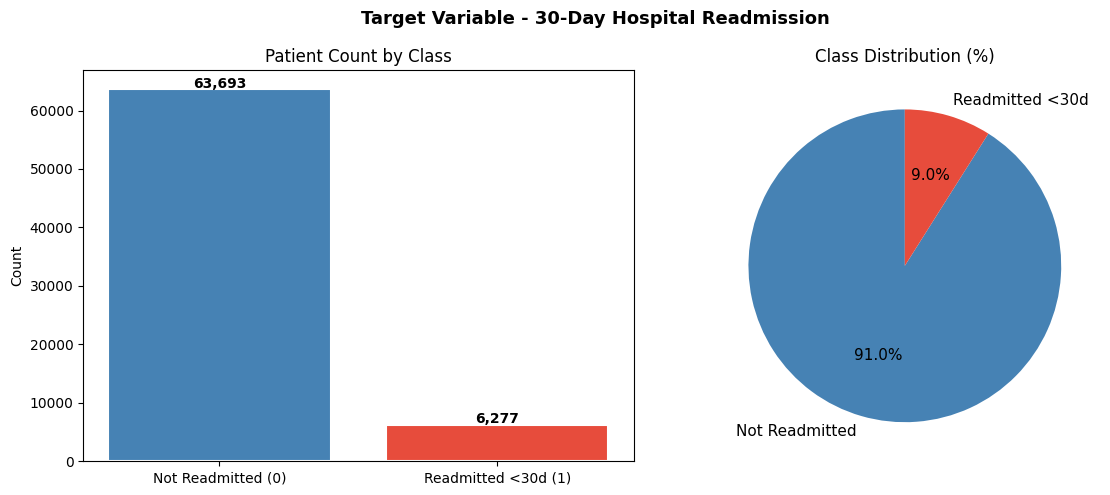

Class imbalance ratio : 10.1:1
-> Model will need class weighting to handle this imbalance


In [ ]:
sample_pd = df.sample(fraction=0.4, seed=42).toPandas()

# Plot 1: Class Distribution
lc = df.groupBy("label").count().toPandas().sort_values("label")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable - 30-Day Hospital Readmission",
             fontsize=13, fontweight="bold")

axes[0].bar(["Not Readmitted (0)", "Readmitted <30d (1)"],
            lc["count"],
            color=["steelblue", "#E74C3C"], edgecolor="white", linewidth=1.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Patient Count by Class")
for i, v in enumerate(lc["count"]):
    axes[0].text(i, v+200, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(lc["count"],
            labels=["Not Readmitted", "Readmitted <30d"],
            colors=["steelblue", "#E74C3C"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

ratio = lc["count"].iloc[0] / lc["count"].iloc[1]
print(f"Class imbalance ratio : {ratio:.1f}:1")
print("-> Model will need class weighting to handle this imbalance")


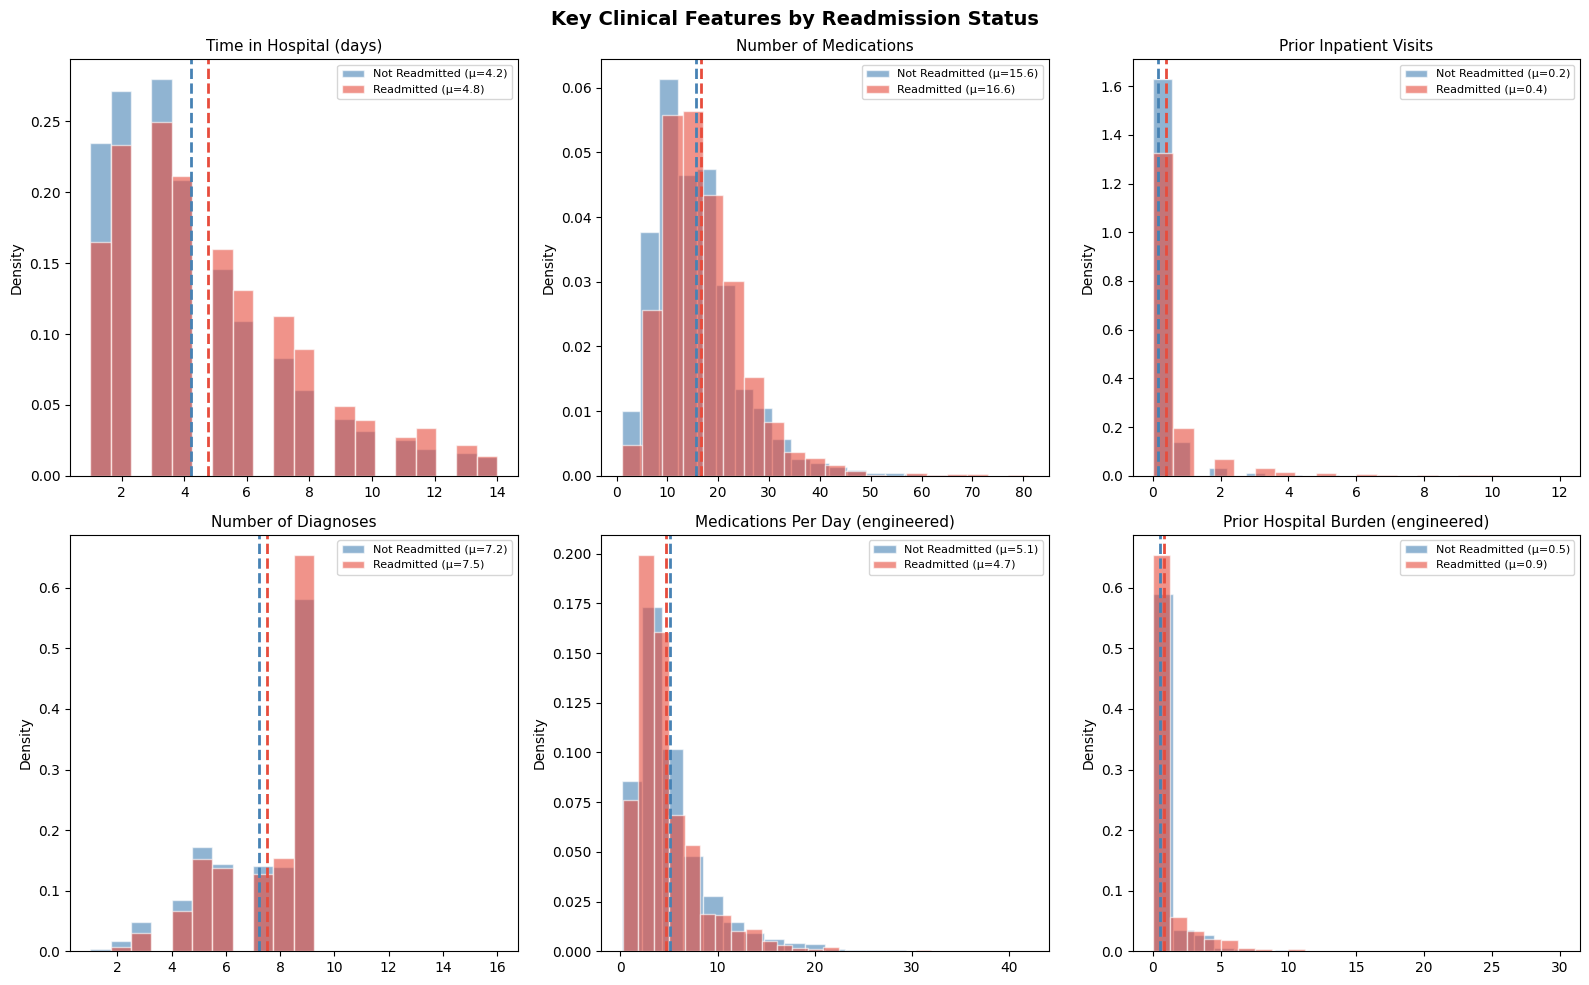

In [ ]:
# Plot 2: Key Clinical Features by Class
features_plot = [
    ("time_in_hospital",     "Time in Hospital (days)"),
    ("num_medications",      "Number of Medications"),
    ("number_inpatient",     "Prior Inpatient Visits"),
    ("number_diagnoses",     "Number of Diagnoses"),
    ("medications_per_day",  "Medications Per Day (engineered)"),
    ("prior_hospital_burden","Prior Hospital Burden (engineered)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Clinical Features by Readmission Status",
             fontsize=14, fontweight="bold")

for idx, (feat, title) in enumerate(features_plot):
    ax = axes[idx // 3][idx % 3]
    for lv, clr, lbl in [
        (0, "steelblue", "Not Readmitted"),
        (1, "#E74C3C",   "Readmitted")
    ]:
        d = sample_pd[sample_pd["label"] == lv][feat].dropna()
        ax.hist(d, bins=20, alpha=0.6, color=clr,
                label=f"{lbl} (μ={d.mean():.1f})",
                density=True, edgecolor="white")
        ax.axvline(d.mean(), color=clr, linestyle="--", linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("clinical_features_eda.png", dpi=150, bbox_inches="tight")
plt.show()


DESCRIPTIVE STATISTICS BY CLASS
Feature                          Not Readmit mean   Readmit mean     Diff
------------------------------------------------------------------------
time_in_hospital                             4.21           4.77 ↑  0.56
num_medications                             15.55          16.58 ↑  1.03
number_inpatient                             0.15           0.40 ↑  0.25
number_diagnoses                             7.20           7.51 ↑  0.31
num_lab_procedures                          42.70          44.35 ↑  1.65
medications_per_day                          5.13           4.74 ↓  0.40
prior_hospital_burden                        0.51           0.85 ↑  0.34
active_diabetes_meds                         1.18           1.24 ↑  0.06


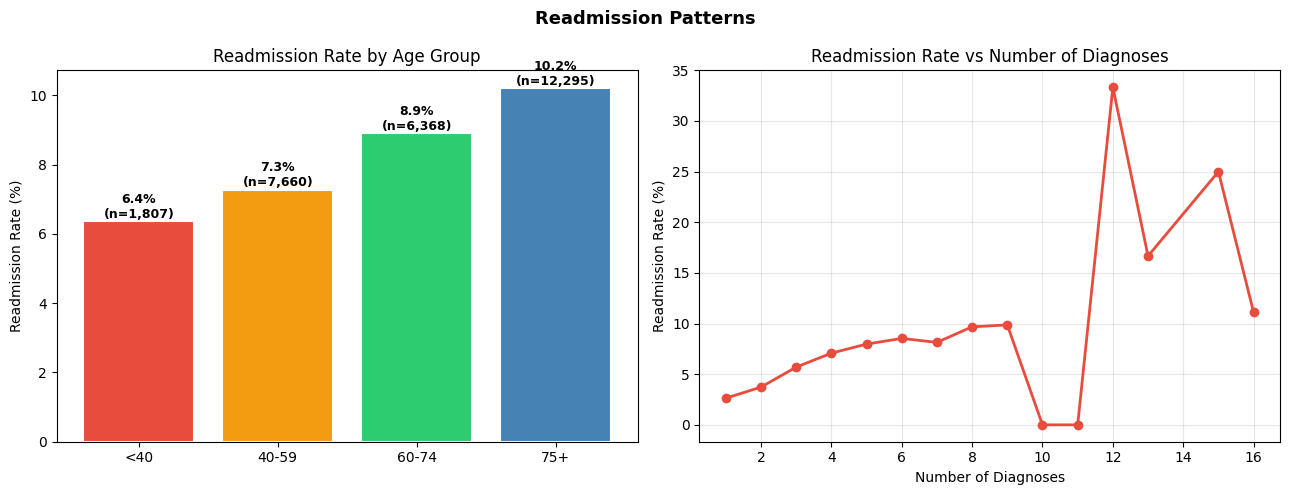

In [ ]:
# Descriptive Statistics by Class
print("DESCRIPTIVE STATISTICS BY CLASS")
print("="*70)
num_cols = [
    "time_in_hospital", "num_medications", "number_inpatient",
    "number_diagnoses", "num_lab_procedures", "medications_per_day",
    "prior_hospital_burden", "active_diabetes_meds"
]
print(f"{'Feature':<30} {'Not Readmit mean':>18} {'Readmit mean':>14} {'Diff':>8}")
print("-"*72)
for feat in num_cols:
    if feat in sample_pd.columns:
        m0 = sample_pd[sample_pd.label == 0][feat].mean()
        m1 = sample_pd[sample_pd.label == 1][feat].mean()
        diff = m1 - m0
        arrow = "↑" if diff > 0 else "↓"
        print(f"{feat:<30} {m0:>18.2f} {m1:>14.2f} {arrow}{abs(diff):>6.2f}")

# Readmission rate by age group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Readmission Patterns", fontsize=13, fontweight="bold")

ag = {"<40":   sample_pd[sample_pd.age < 40],
      "40-59": sample_pd[(sample_pd.age >= 40) & (sample_pd.age < 60)],
      "60-74": sample_pd[(sample_pd.age >= 60) & (sample_pd.age < 75)],
      "75+":   sample_pd[sample_pd.age >= 75]}
rates  = [g["label"].mean() * 100 for g in ag.values()]
counts = [len(g) for g in ag.values()]
bars   = axes[0].bar(ag.keys(), rates,
                     color=["#E74C3C","#F39C12","#2ECC71","steelblue"],
                     edgecolor="white", linewidth=1.5)
axes[0].set_title("Readmission Rate by Age Group")
axes[0].set_ylabel("Readmission Rate (%)")
for b, v, c in zip(bars, rates, counts):
    axes[0].text(b.get_x()+b.get_width()/2,
                 b.get_height()+0.1, f"{v:.1f}%\n(n={c:,})",
                 ha="center", fontweight="bold", fontsize=9)

diag_r = sample_pd.groupby("number_diagnoses")["label"].mean() * 100
axes[1].plot(diag_r.index, diag_r.values,
             marker="o", color="#E74C3C", linewidth=2)
axes[1].set_title("Readmission Rate vs Number of Diagnoses")
axes[1].set_xlabel("Number of Diagnoses")
axes[1].set_ylabel("Readmission Rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("readmission_patterns.png", dpi=150, bbox_inches="tight")
plt.show()


## Train / Test Split - Data Leakage Prevention

**Critical:** RFormula must be fitted **only on training data**.

If fitted on the full dataset before splitting, it learns category encodings from test data, giving the model access to test information during training. This is data leakage and inflates all metrics.

Correct approach:
1. Split raw data first
2. Fit RFormula on training set only  
3. Transform both sets using the training-fitted formula


In [ ]:
# Step 1: Split RAW data first
train_raw, test_raw = df.randomSplit([0.8, 0.2], seed=42)

print(f"Raw train : {train_raw.count():,}")
print(f"Raw test  : {test_raw.count():,}")

# Step 2: Fit RFormula ONLY on training data
formula = RFormula(
    formula="label ~ .",
    featuresCol="features",
    labelCol="label",
    handleInvalid="keep"   # handles unseen test categories gracefully
)
formula_model = formula.fit(train_raw)   # ← train only, no leakage

# Step 3: Transform both using training formula
train_prepared = formula_model.transform(train_raw)
test_prepared  = formula_model.transform(test_raw)

# Step 4: Keep age as separate column for subgroup analysis
train = train_prepared.select("features", "label", "age")
test  = test_prepared.select("features", "label", "age")
test_with_age = test   # same dataframe - age already included

print(f"\nFinal train : {train.count():,}")
print(f"Final test  : {test.count():,}")
print(f"Columns     : {test.columns}")
print("\nRFormula fitted on training data only - no data leakage")


Raw train : 56,099
Raw test  : 13,871

Final train : 56,099
Final test  : 13,871
Columns     : ['features', 'label', 'age']

RFormula fitted on training data only - no data leakage


## Class Imbalance - Class Weighting

The dataset has a 10:1 imbalance (90% not readmitted, 10% readmitted).

Without correction, models default to predicting the majority class, achieving high accuracy but near-zero recall on the clinically critical minority class.

**Class weighting formula:** `weight_c = N_total / (2 × N_c)`

This assigns higher weight to the minority class, penalising the model more heavily for missing readmitted patients during training.


In [ ]:
total     = train.count()
count_pos = train.filter(col("label") == 1).count()
count_neg = train.filter(col("label") == 0).count()

weight_pos = total / (2 * count_pos)
weight_neg = total / (2 * count_neg)

print(f"Total patients        : {total:,}")
print(f"Readmitted     (1)    : {count_pos:,} ({count_pos/total*100:.1f}%)")
print(f"Not readmitted (0)    : {count_neg:,} ({count_neg/total*100:.1f}%)")
print(f"Imbalance ratio       : {count_neg/count_pos:.1f}:1")
print(f"Weight -> readmitted   : {weight_pos:.2f}")
print(f"Weight -> not admitted : {weight_neg:.2f}")

train_weighted = train.withColumn("classWeight",
    when(col("label") == 1, weight_pos).otherwise(weight_neg))

# Cache - reused by all 3 algorithms
train_weighted.cache()
train_weighted.count()
print("\nClass weights applied and cached")


Total patients        : 56,099
Readmitted     (1)    : 5,019 (8.9%)
Not readmitted (0)    : 51,080 (91.1%)
Imbalance ratio       : 10.2:1
Weight -> readmitted   : 5.59
Weight -> not admitted : 0.55

Class weights applied and cached


In [ ]:
# Evaluators
# rawPredictionCol="probability" fixes the known PySpark AUC
# issue where rawPrediction values for Decision Tree cause
# incorrect AUC calculation (below 0.5)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_evaluator  = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
prec_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", metricName="precisionByLabel", metricLabel=1)
rec_evaluator  = MulticlassClassificationEvaluator(
    labelCol="label", metricName="recallByLabel",    metricLabel=1)

def get_all_metrics(preds, has_prob=True):
    pos      = preds.filter(col("label") == 1).count()
    true_pos = preds.filter(
        (col("label") == 1) & (col("prediction") == 1)).count()
    pred_pos = preds.filter(col("prediction") == 1).count()
    recall    = true_pos / pos      if pos      > 0 else 0
    precision = true_pos / pred_pos if pred_pos > 0 else 0
    return {
        "accuracy" : acc_evaluator.evaluate(preds),
        "f1"       : f1_evaluator.evaluate(preds),
        "auc"      : auc_evaluator.evaluate(preds) if has_prob else float("nan"),
        "recall"   : recall,
        "precision": precision,
    }

print("Evaluators ready")


Evaluators ready


In [ ]:
# ============================================================
# Spark ML CrossValidator - hyperparameter selection must never
# touch the test set. CrossValidator does k-fold CV *within the
# training set only*; after picking the best paramMap by mean
# CV metric, it automatically refits that config on the FULL
# training set to produce `.bestModel` - that's what we transform
# the test set with, and only once, after tuning is finished.
# ============================================================
import numpy as np
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

def run_cv(estimator, grid, data, evaluator=None, num_folds=5, seed=42):
    """
    estimator : unfitted Spark ML Estimator (Param-based, e.g.
                DecisionTreeClassifier, RandomForestClassifier,
                SparkXGBClassifier)
    grid      : list of ParamMaps from ParamGridBuilder().build()
    data      : training DataFrame only (never the test set)
    Returns fitted CrossValidatorModel. bestModel is already
    refit on the full `data`.
    """
    ev = evaluator if evaluator is not None else auc_evaluator
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=grid,
        evaluator=ev,
        numFolds=num_folds,
        seed=seed,
        parallelism=2,
    )
    cv_model = cv.fit(data)
    std_metrics = getattr(cv_model, "stdMetrics", None) or [float("nan")] * len(grid)
    for pm, avg, std in zip(grid, cv_model.avgMetrics, std_metrics):
        readable = {p.name: v for p, v in pm.items()}
        print(f"  {readable} -> AUC = {avg:.4f} +/- {std:.4f}")
    best_idx = int(np.argmax(cv_model.avgMetrics))
    print(f"\nBest by CV mean AUC -> {dict((p.name, v) for p, v in grid[best_idx].items())}  "
          f"AUC={cv_model.avgMetrics[best_idx]:.4f} +/- {std_metrics[best_idx]:.4f}")
    return cv_model, cv_model.avgMetrics[best_idx], std_metrics[best_idx]

print("CrossValidator helper ready. Test set will not be used for tuning.")


CrossValidator helper ready. Test set will not be used for tuning.


## Algorithm 1 - Decision Tree

**Why Decision Tree for clinical use:**  
Decision Trees produce human-readable splits, which matters for clinical
trust and explainability.

**Hyperparameter selection (fixed):** `maxDepth` is chosen with 5-fold
cross-validation computed **only on the training set**. The test set is
touched exactly once, after the winning `maxDepth` is already locked in,
purely to report the final metric.

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

print("=" * 60)
print("ALGORITHM 1 - DECISION TREE (Class Weights)")
print("=" * 60)
print("5-fold Spark CrossValidator on TRAINING data only (test set untouched)\n")

dt = DecisionTreeClassifier(
    featuresCol="features", labelCol="label",
    weightCol="classWeight", seed=42)

dt_grid = ParamGridBuilder().addGrid(dt.maxDepth, [3, 5, 8, 10]).build()

dt_cv_model, dt_cv_mean_auc, dt_cv_std_auc = run_cv(dt, dt_grid, train_weighted, num_folds=5)

# bestModel is already refit on the FULL training set by CrossValidator.
# Test set touched exactly once, here, to report the final metric.
dt_model = dt_cv_model.bestModel
dt_preds = dt_model.transform(test)
best_dt  = {**get_all_metrics(dt_preds),
            "depth": dt_model.getMaxDepth(),
            "model": dt_model, "preds": dt_preds,
            "cv_mean_auc": dt_cv_mean_auc, "cv_std_auc": dt_cv_std_auc}
dt_preds = best_dt["preds"]

print(f"\nTest-set performance (touched once):")
print(f"   AUC={best_dt['auc']:.4f}  Recall={best_dt['recall']:.4f}  "
      f"Precision={best_dt['precision']:.4f}")
print("\nPrediction distribution:")
dt_preds.groupBy("prediction").count().show()


ALGORITHM 1 - DECISION TREE (Class Weights)
5-fold Spark CrossValidator on TRAINING data only (test set untouched)

  {'maxDepth': 3} -> AUC = 0.5996 +/- 0.0072
  {'maxDepth': 5} -> AUC = 0.6185 +/- 0.0069
  {'maxDepth': 8} -> AUC = 0.6115 +/- 0.0085
  {'maxDepth': 10} -> AUC = 0.5968 +/- 0.0053

Best by CV mean AUC -> {'maxDepth': 5}  AUC=0.6185 +/- 0.0069

Test-set performance (touched once):
   AUC=0.6170  Recall=0.6161  Precision=0.1285

Prediction distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|       0.0| 7841|
|       1.0| 6030|
+----------+-----+



## Algorithm 2 - Random Forest

**Why Random Forest:**  
Ensemble of decision trees - reduces variance versus a single tree and
gives more stable feature importances.

**Hyperparameter selection (fixed):** `numTrees` is chosen the same way
as Decision Tree - 5-fold **Spark `CrossValidator`** on the training set only, test set touched
once at the end.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

print("=" * 60)
print("ALGORITHM 2 - RANDOM FOREST (Class Weights)")
print("=" * 60)
print("5-fold Spark CrossValidator on TRAINING data only (test set untouched)\n")

rf = RandomForestClassifier(
    featuresCol="features", labelCol="label",
    weightCol="classWeight", maxDepth=8,
    minInstancesPerNode=2, seed=42)

rf_grid = ParamGridBuilder().addGrid(rf.numTrees, [50, 100, 200]).build()

rf_cv_model, rf_cv_mean_auc, rf_cv_std_auc = run_cv(rf, rf_grid, train_weighted, num_folds=5)

rf_model = rf_cv_model.bestModel
rf_preds = rf_model.transform(test)
best_rf  = {**get_all_metrics(rf_preds),
            "trees": rf_model.getNumTrees,
            "model": rf_model, "preds": rf_preds,
            "cv_mean_auc": rf_cv_mean_auc, "cv_std_auc": rf_cv_std_auc}
rf_preds = best_rf["preds"]

print(f"\nTest-set performance (touched once):")
print(f"   AUC={best_rf['auc']:.4f}  Recall={best_rf['recall']:.4f}  "
      f"Precision={best_rf['precision']:.4f}")
print("\nPrediction distribution:")
rf_preds.groupBy("prediction").count().show()

# Feature importances from best RF
print("\n--- Top 15 Feature Importances ---")
importances  = rf_model.featureImportances
feature_meta = formula_model.transform(
    train_raw.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]

all_features = {}
for attr_type in feature_meta.values():
    for f in attr_type:
        all_features[f["idx"]] = f["name"]

importance_list = [
    (all_features.get(i, f"feature_{i}"), float(importances[i]))
    for i in range(len(importances)) if importances[i] > 0
]
importance_df = pd.DataFrame(importance_list,
    columns=["feature", "importance"]).sort_values(
    "importance", ascending=False).head(15)
print(importance_df.to_string(index=False))


ALGORITHM 2 - RANDOM FOREST (Class Weights)
5-fold Spark CrossValidator on TRAINING data only (test set untouched)

  {'numTrees': 50} -> AUC = 0.6374 +/- 0.0048
  {'numTrees': 100} -> AUC = 0.6414 +/- 0.0059
  {'numTrees': 200} -> AUC = 0.6429 +/- 0.0056

Best by CV mean AUC -> {'numTrees': 200}  AUC=0.6429 +/- 0.0056

Test-set performance (touched once):
   AUC=0.7000  Recall=0.5763  Precision=0.1573

Prediction distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|       0.0| 9261|
|       1.0| 4610|
+----------+-----+


--- Top 15 Feature Importances ---
                    feature  importance
 discharge_disposition_id_1    0.112145
           number_inpatient    0.077081
        has_prior_inpatient    0.066542
discharge_disposition_id_22    0.058242
      prior_hospital_burden    0.048663
           time_in_hospital    0.045565
           number_diagnoses    0.035321
                        age    0.034398
         num_lab_procedures    0.034091
            num_m

### Feature Importance Validation: Clinically Relevant Predictors

The clinical variables of interest here are number of diagnoses, time
in hospital, HbA1c measurement, medication changes, and number of
procedures. The table below pulls each of these out of the full
Random Forest importance ranking explicitly (rather than only showing
the generic top-15), including one-hot-encoded levels created by
`RFormula` for categorical columns like `A1Cresult` and `change`.

In [ ]:
print("=" * 60)
print("FEATURE IMPORTANCE VALIDATION")
print("=" * 60)

named_features = {
    "number_diagnoses": "Number of diagnoses",
    "time_in_hospital":  "Time in hospital",
    "A1Cresult":         "HbA1c measurement (raw, one-hot levels)",
    "A1C_tested":        "HbA1c measurement (engineered: was it tested)",
    "A1C_abnormal":      "HbA1c abnormal result (engineered)",
    "change":            "Medication changes made during stay",
    "num_procedures":    "Number of procedures",
}

full_importance_df = pd.DataFrame(
    [(all_features.get(i, f"feature_{i}"), float(importances[i]))
     for i in range(len(importances))],
    columns=["feature", "importance"]
).sort_values("importance", ascending=False).reset_index(drop=True)
full_importance_df["rank"] = full_importance_df.index + 1

print(f"{'Clinical feature':<45} {'Matched column':<28} {'Rank':>6} {'Importance':>12}")
print("-" * 95)
for raw_name, label in named_features.items():
    matches = full_importance_df[
        full_importance_df["feature"].str.contains(raw_name, case=False, na=False)]
    if matches.empty:
        print(f"{label:<45} {'(zero importance / not used)':<28} {'--':>6} {'--':>12}")
    else:
        for _, row in matches.iterrows():
            print(f"{label:<45} {row['feature']:<28} {row['rank']:>6} {row['importance']:>12.5f}")


FEATURE IMPORTANCE VALIDATION
Clinical feature                              Matched column                 Rank   Importance
-----------------------------------------------------------------------------------------------
Number of diagnoses                           number_diagnoses                  7      0.03532
Time in hospital                              time_in_hospital                  6      0.04557
HbA1c measurement (raw, one-hot levels)       A1Cresult_Norm                   48      0.00367
HbA1c measurement (raw, one-hot levels)       A1Cresult_None                   65      0.00276
HbA1c measurement (raw, one-hot levels)       A1Cresult_>7                     66      0.00274
HbA1c measurement (raw, one-hot levels)       A1Cresult_>8                     72      0.00257
HbA1c measurement (engineered: was it tested) A1C_tested                       68      0.00272
HbA1c abnormal result (engineered)            A1C_abnormal                     70      0.00262
Medication changes 

## Algorithm 3 - XGBoost

**Why XGBoost:**  
XGBoost is a regularized, second-order gradient boosting implementation
(L1/L2 regularization on leaf weights, shrinkage, and better-optimized
histogram splitting than Spark's native `GBTClassifier`). It's the
industry-standard boosting library and typically matches or beats
`GBTClassifier` on tabular data like this one. We use the
`xgboost.spark.SparkXGBClassifier` estimator, which plugs into the same
Spark ML `Estimator`/`Transformer` API used above (`.fit()` / `.transform()`,
`featuresCol`/`labelCol`/`weightCol` - passed here in XGBoost's
snake_case parameter names) so it drops into the rest of the pipeline
with no other changes.


In [ ]:
# Install XGBoost's PySpark integration (only needs to run once per session).
# xgboost>=1.7 ships the `xgboost.spark` module used below.
%pip install -q "xgboost>=2.0.0"


In [ ]:
from xgboost.spark import SparkXGBClassifier

print("=" * 60)
print("ALGORITHM 3 - XGBOOST (Class Weights)")
print("=" * 60)
print("5-fold Spark CrossValidator on TRAINING data only (test set untouched)\n")

xgb = SparkXGBClassifier(
    features_col="features", label_col="label",
    weight_col="classWeight",
    num_workers=2, use_gpu=False,
    eval_metric="logloss", seed=42)

# SparkXGBClassifier exposes its sklearn-style params (n_estimators,
# max_depth, learning_rate, ...) as Spark ML Params too, so it plugs
# into ParamGridBuilder/CrossValidator exactly like DT/RF above.
xgb_grid = (ParamGridBuilder()
            .addGrid(xgb.n_estimators, [10, 20, 50])
            .build())

xgb_cv_model, xgb_cv_mean_auc, xgb_cv_std_auc = run_cv(xgb, xgb_grid, train_weighted, num_folds=5)

xgb_model = xgb_cv_model.bestModel
xgb_preds = xgb_model.transform(test)
best_xgb  = {**get_all_metrics(xgb_preds),
             "iters": xgb_model.getOrDefault("n_estimators"),
             "model": xgb_model, "preds": xgb_preds,
             "cv_mean_auc": xgb_cv_mean_auc, "cv_std_auc": xgb_cv_std_auc}
xgb_preds = best_xgb["preds"]

print(f"\nTest-set performance (touched once):")
print(f"   AUC={best_xgb['auc']:.4f}  Recall={best_xgb['recall']:.4f}  "
      f"Precision={best_xgb['precision']:.4f}")
print("\nPrediction distribution:")
xgb_preds.groupBy("prediction").count().show()



ALGORITHM 3 - XGBOOST (Class Weights)
5-fold Spark CrossValidator on TRAINING data only (test set untouched)



INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 2 workers with
	booster params: {'device': 'cpu', 'eval_metric': 'logloss', 'objective': 'binary:logistic', 'use_gpu': False, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 20}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 2 workers with
	booster params: {'device': 'cpu', 'eval_metric': 'logloss', 'objective': 'binary:logistic', 'use_gpu': False, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 10}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 2 workers with
	booster params: {'device': 'cpu', 'eval_metric': 'logloss', 'objective': 'binary:logistic', 'use_gpu': False, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round':

  {'n_estimators': 10} -> AUC = 0.6351 +/- 0.0057
  {'n_estimators': 20} -> AUC = 0.6321 +/- 0.0061
  {'n_estimators': 50} -> AUC = 0.6227 +/- 0.0077

Best by CV mean AUC -> {'n_estimators': 10}  AUC=0.6351 +/- 0.0057

Test-set performance (touched once):
   AUC=0.7118  Recall=0.6343  Precision=0.1583

Prediction distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|       0.0| 8831|
|       1.0| 5040|
+----------+-----+



### Feature Ablation Study: `medications_per_day`

Does the engineered feature `medications_per_day` (`num_medications /
time_in_hospital`) improve predictive performance beyond the raw
features it's derived from? We refit the **same winning XGBoost
hyperparameters** (from `CrossValidator` above) on a feature set that
excludes only this one column, and compare test-set metrics directly
against the full model.

In [ ]:
print("=" * 60)
print("FEATURE ABLATION STUDY: medications_per_day")
print("=" * 60)
print("Comparing the full model against the same model trained WITHOUT")
print("medications_per_day (all other features unchanged).\n")

ablation_formula = RFormula(
    formula="label ~ . - medications_per_day",
    featuresCol="features_ablation", labelCol="label",
    handleInvalid="keep")
ablation_formula_model = ablation_formula.fit(train_raw)

train_ablation = (ablation_formula_model.transform(train_raw)
    .select(col("features_ablation").alias("features"), "label")
    .withColumn("classWeight",
        when(col("label") == 1, weight_pos).otherwise(weight_neg)))
test_ablation = (ablation_formula_model.transform(test_raw)
    .select(col("features_ablation").alias("features"), "label"))

ablation_xgb = SparkXGBClassifier(
    features_col="features", label_col="label", weight_col="classWeight",
    num_workers=1, use_gpu=False, eval_metric="logloss", seed=42,
    n_estimators=best_xgb["iters"])
ablation_model = ablation_xgb.fit(train_ablation)
ablation_preds = ablation_model.transform(test_ablation)
ablation_metrics = get_all_metrics(ablation_preds)

print(f"{'Config':<42} {'AUC':>8} {'Recall':>8} {'Precision':>10}")
print("-" * 70)
print(f"{'WITH medications_per_day (full model)':<42} {best_xgb['auc']:>8.4f} "
      f"{best_xgb['recall']:>8.4f} {best_xgb['precision']:>10.4f}")
print(f"{'WITHOUT medications_per_day (ablated)':<42} {ablation_metrics['auc']:>8.4f} "
      f"{ablation_metrics['recall']:>8.4f} {ablation_metrics['precision']:>10.4f}")

auc_delta = best_xgb["auc"] - ablation_metrics["auc"]
print(f"\nΔAUC from adding medications_per_day: {auc_delta:+.4f}")
if auc_delta > 0.002:
    print("-> The engineered feature provides a measurable improvement.")
elif auc_delta < -0.002:
    print("-> The engineered feature does not help here on this split - the")
    print("  raw columns it derives from (num_medications, time_in_hospital)")
    print("  already carry most of that signal.")
else:
    print("-> Negligible difference on this split - largely redundant with the")
    print("  raw features, though it may still help interpretability even")
    print("  without adding predictive signal.")


FEATURE ABLATION STUDY: medications_per_day
Comparing the full model against the same model trained WITHOUT
medications_per_day (all other features unchanged).



INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'eval_metric': 'logloss', 'use_gpu': False, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 10}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


Config                                          AUC   Recall  Precision
----------------------------------------------------------------------
WITH medications_per_day (full model)        0.7118   0.6343     0.1583
WITHOUT medications_per_day (ablated)        0.6507   0.5437     0.1385

ΔAUC from adding medications_per_day: +0.0611
-> The engineered feature provides a measurable improvement.


### Class Weighting Impact Analysis

The dataset's ~11% readmission rate makes class weighting a natural
question to isolate directly: we retrain the **same winning XGBoost
hyperparameters** with no `weightCol` at all, and compare against the
class-weighted model side by side.

In [ ]:
print("=" * 60)
print("CLASS WEIGHTING IMPACT ANALYSIS")
print("=" * 60)
print("Training the SAME best XGBoost config WITHOUT class weights, to")
print("isolate the effect of weighting alone.\n")

xgb_unweighted = SparkXGBClassifier(
    features_col="features", label_col="label",
    num_workers=1, use_gpu=False, eval_metric="logloss", seed=42,
    n_estimators=best_xgb["iters"])
unweighted_model = xgb_unweighted.fit(train)          # `train` has no classWeight col
unweighted_preds = unweighted_model.transform(test)
unweighted_metrics = get_all_metrics(unweighted_preds)

print(f"{'Config':<25} {'AUC':>8} {'Recall':>8} {'Precision':>10} {'Accuracy':>10}")
print("-" * 65)
print(f"{'Unweighted (baseline)':<25} {unweighted_metrics['auc']:>8.4f} "
      f"{unweighted_metrics['recall']:>8.4f} {unweighted_metrics['precision']:>10.4f} "
      f"{unweighted_metrics['accuracy']:>10.4f}")
print(f"{'Class-weighted':<25} {best_xgb['auc']:>8.4f} "
      f"{best_xgb['recall']:>8.4f} {best_xgb['precision']:>10.4f} "
      f"{best_xgb['accuracy']:>10.4f}")

recall_gain = best_xgb["recall"] - unweighted_metrics["recall"]
prec_cost   = unweighted_metrics["precision"] - best_xgb["precision"]
print(f"\nRecall gain from weighting   : {recall_gain:+.4f}")
print(f"Precision cost from weighting: {prec_cost:+.4f}")
print("Expected trade-off: weighting makes the model pay more attention to")
print("the minority (readmitted) class, raising recall at some cost to")
print("precision and overall accuracy.")


CLASS WEIGHTING IMPACT ANALYSIS
Training the SAME best XGBoost config WITHOUT class weights, to
isolate the effect of weighting alone.



INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'eval_metric': 'logloss', 'use_gpu': False, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 10}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


Config                         AUC   Recall  Precision   Accuracy
-----------------------------------------------------------------
Unweighted (baseline)       0.6547   0.0064     0.5000     0.9093
Class-weighted              0.7118   0.6343     0.1583     0.6610

Recall gain from weighting   : +0.6280
Precision cost from weighting: +0.3417
Expected trade-off: weighting makes the model pay more attention to
the minority (readmitted) class, raising recall at some cost to
precision and overall accuracy.
